In [1]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from scipy import stats
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score 
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

In [2]:
wine=load_wine()

In [6]:
wine_X_train, wine_X_test, wine_y_train, wine_y_test = train_test_split(
    wine.data, wine.target, test_size=0.5, random_state=1)

In [7]:
# Размер обучающей выборки
wine_X_train.shape, wine_y_train.shape

((89, 13), (89,))

In [8]:
# Размер тестовой выборки
wine_X_test.shape, wine_y_test.shape

((89, 13), (89,))

In [9]:
from scipy.optimize import fmin_tnc
from IPython.display import Image
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import SGDClassifier

In [11]:
# Определение функции
# f(0)=0.5
x = np.linspace(-7, 7, 31)
y = 1 / (1 + np.exp(-x))
list(zip(x,y))

[(np.float64(-7.0), np.float64(0.0009110511944006454)),
 (np.float64(-6.533333333333333), np.float64(0.0014520391100099122)),
 (np.float64(-6.066666666666666), np.float64(0.0023135251651203942)),
 (np.float64(-5.6), np.float64(0.003684239899435989)),
 (np.float64(-5.133333333333333), np.float64(0.005862302196338335)),
 (np.float64(-4.666666666666666), np.float64(0.009315959345066693)),
 (np.float64(-4.2), np.float64(0.014774031693273055)),
 (np.float64(-3.7333333333333334), np.float64(0.023354516476977092)),
 (np.float64(-3.2666666666666666), np.float64(0.03673259067202974)),
 (np.float64(-2.8), np.float64(0.057324175898868755)),
 (np.float64(-2.333333333333333), np.float64(0.08839967720705845)),
 (np.float64(-1.8666666666666663), np.float64(0.1339278883240737)),
 (np.float64(-1.4000000000000004), np.float64(0.1978161114414182)),
 (np.float64(-0.9333333333333336), np.float64(0.28224894304225995)),
 (np.float64(-0.4666666666666668), np.float64(0.3854055017324505)),
 (np.float64(0.0), np

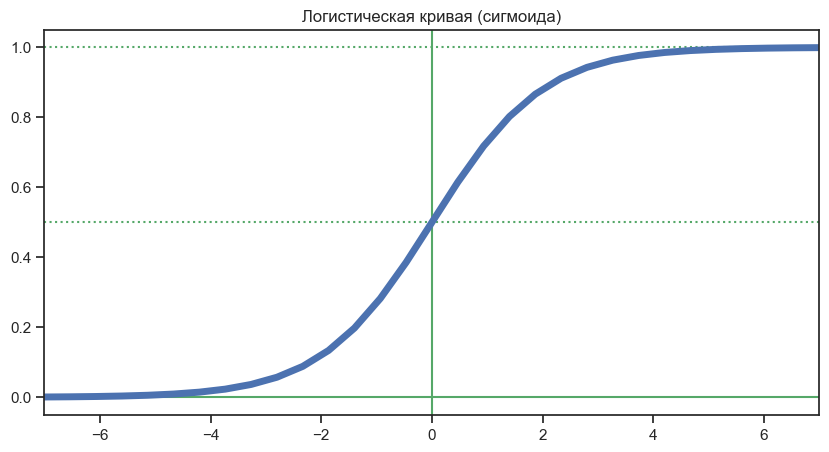

In [12]:
# Вывод графика и осей
plt.figure(figsize=(10, 5))
plt.plot([-7, 7], [0, 0], "g-")
plt.plot([-7, 7], [0.5, 0.5], "g:")
plt.plot([-7, 7], [1, 1], "g:")
plt.plot([0, 0], [-1.1, 1.1], "g-")
plt.plot(x, y, "b-", linewidth=5)
plt.axis([-7, 7, -0.05, 1.05])
plt.title('Логистическая кривая (сигмоида)')
plt.show() 

In [14]:
# Подготовка данных
wine_x_ds = pd.DataFrame(data=wine['data'], columns=wine['feature_names'])
wine_x_ds_lr = wine_x_ds[['flavanoids', 'proanthocyanins']]
wine_x_ds_lr['x0'] = 1
wine_x_ds_lr['target'] = wine.target
wine_x_ds_lr.head()

C:\Users\masha\AppData\Local\Temp\ipykernel_3596\1675810583.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wine_x_ds_lr['x0'] = 1
C:\Users\masha\AppData\Local\Temp\ipykernel_3596\1675810583.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wine_x_ds_lr['target'] = wine.target


,flavanoids,proanthocyanins,x0,target
0,3.06,2.29,1,0
1,2.76,1.28,1,0
2,3.24,2.81,1,0
3,3.49,2.18,1,0
4,2.69,1.82,1,0


In [15]:
def convert_target_to_binary(array:np.ndarray, target:int) -> np.ndarray:
    # Если целевой признак совпадает с указанным, то 1 иначе 0
    res = [1 if x==target else 0 for x in array]
    return res

In [16]:
bin_wine_y = convert_target_to_binary(wine.target, 0)

In [17]:
wine_x_ds_lr['target_bin'] = bin_wine_y
wine_x_ds_lr.head()

C:\Users\masha\AppData\Local\Temp\ipykernel_3596\974887079.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wine_x_ds_lr['target_bin'] = bin_wine_y


,flavanoids,proanthocyanins,x0,target,target_bin
0,3.06,2.29,1,0,1
1,2.76,1.28,1,0,1
2,3.24,2.81,1,0,1
3,3.49,2.18,1,0,1
4,2.69,1.82,1,0,1


C:\Users\masha\AppData\Local\Temp\ipykernel_3596\783943327.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_viz[idx, 0], X_viz[idx, 1],


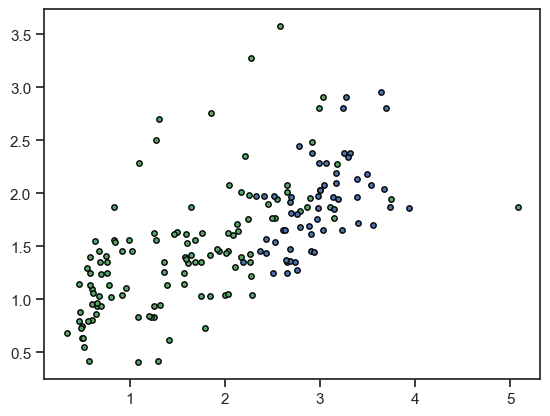

In [18]:
# Визуализация данных
colors = "gb"
#X_viz = wine.data[:, [1,2]]
X_viz = wine_x_ds_lr[['flavanoids', 'proanthocyanins']].values
y_viz = wine_x_ds_lr['target_bin'].values
n_classes = len(np.unique(y_viz))
for i, color in zip(range(n_classes), colors):
    idx = np.where(y_viz == i)
    plt.scatter(X_viz[idx, 0], X_viz[idx, 1], 
                c=color, 
                cmap=plt.cm.RdYlBu, 
                edgecolor='black', s=15)
plt.show()    

In [19]:
# Реализация градиентного спуска
def sigmoid(x):
    '''
    Функция - сигмоида
    '''
    return 1 / (1 + np.exp(-x))

def proba(b, x):
    '''
    Вероятность единичного класса
    '''
    return sigmoid(np.dot(x,b))

def cost_function(b, x, y):
    '''
    Функция потерь
    '''
    k = x.shape[0]
    res = -(1 / k) * np.sum(
        y * np.log(proba(b, x)) 
        + (1 - y) * np.log(1 - proba(b, x)))
    return res

def gradient(b, x, y):
    '''
    Определение градиента
    '''
    k = x.shape[0]
    res = (1 / k) * np.dot(
        x.T, (proba(b, x) - y))

def optimize_lr(x, y, b):
    '''
    Для оптимизации используется функция 
    scipy.optimize.fmin_tnc
    '''
    opt_weights = fmin_tnc(
        func=cost_function, 
        x0=b,          
        fprime=gradient,
        approx_grad=True,
        args=(x, y))
    return opt_weights[0]    

In [20]:
opt_x = wine_x_ds_lr[['x0', 'flavanoids', 'proanthocyanins']].values
opt_x[:5]

array([[1.  , 3.06, 2.29],
       [1.  , 2.76, 1.28],
       [1.  , 3.24, 2.81],
       [1.  , 3.49, 2.18],
       [1.  , 2.69, 1.82]])

In [21]:
opt_y = wine_x_ds_lr['target_bin']
opt_y[:5]

0    1
1    1
2    1
3    1
4    1
Name: target_bin, dtype: int64

In [22]:
b_init = np.zeros(3)
b_init

array([0., 0., 0.])

In [23]:
b_res = optimize_lr(opt_x, opt_y, b_init)
b_res

array([-7.23299103,  3.49491599, -1.07540537])

In [28]:
def vis_lr(b):
    '''
    Визуализация результата
    '''    
    colors = "gb"
    X_viz = wine_x_ds_lr[['flavanoids', 'proanthocyanins']].values
    y_viz = wine_x_ds_lr['target_bin'].values
    n_classes = len(np.unique(y_viz))
    for i, color in zip(range(n_classes), colors):
        idx = np.where(y_viz == i)
        plt.scatter(X_viz[idx, 0], X_viz[idx, 1], 
                    c=y_viz[idx], 
                    cmap=plt.cm.RdYlBu, 
                    edgecolor='black', s=15)

    t1 = wine_x_ds_lr['flavanoids'].values    
    t2 = -((b[0]+np.dot(b[1], t1))/b[2])
    plt.plot(t1, t2, 'r', linewidth=2.0)   
    plt.show()    

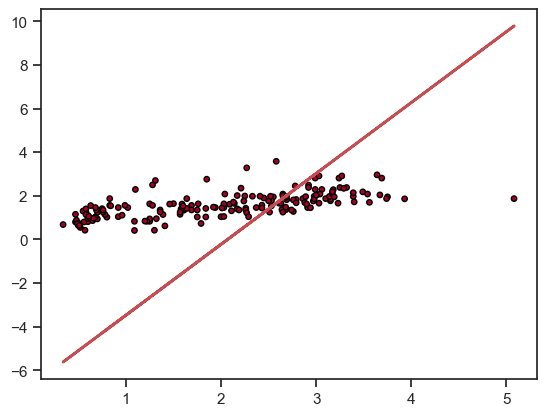

In [29]:
vis_lr(b_res)

In [31]:
# Используем датасет wine с двумя первыми признаками
wine_X = wine.data[:, :2]
wine_y = wine.target

In [41]:
def make_meshgrid(x, y, h=.02):
    """Create a mesh of points to plot in

    Parameters
    ----------
    x: data to base x-axis meshgrid on
    y: data to base y-axis meshgrid on
    h: stepsize for meshgrid, optional

    Returns
    -------
    xx, yy : ndarray
    """
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    ax: matplotlib axes object
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    #Можно проверить все ли метки классов предсказываются
    #print(np.unique(Z))
    out = ax.contourf(xx, yy, Z, **params)
    return out


def plot_cl(clf):
    title = clf.__repr__
    clf.fit(wine_X, wine_y)
    fig, ax = plt.subplots(figsize=(5,5))
    X0, X1 = wine_X[:, 0], wine_X[:, 1]
    xx, yy = make_meshgrid(X0, X1)
    plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
    ax.scatter(X0, X1, c=wine_y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xlabel('Alcohol')
    ax.set_ylabel('Malic acid')
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)
    plt.show()

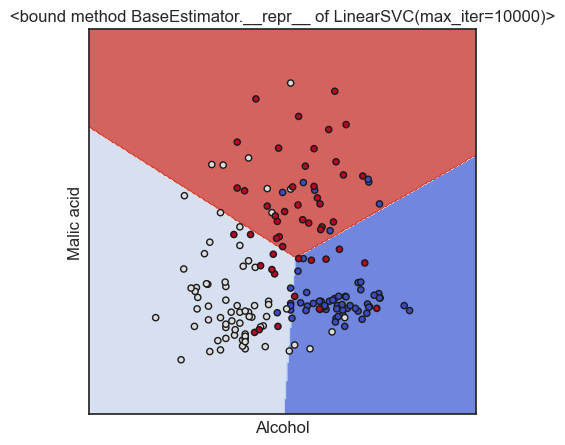

In [42]:
plot_cl(LinearSVC(C=1.0, max_iter=10000))

In [34]:
from sklearn.svm import SVC, NuSVC, LinearSVC, OneClassSVM, SVR, NuSVR, LinearSVR

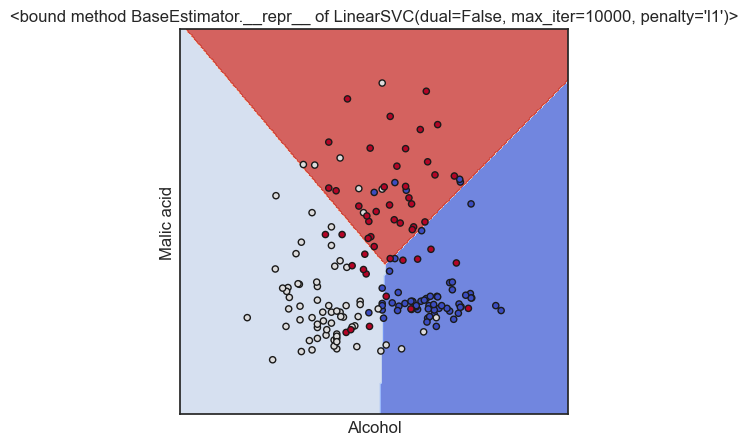

In [43]:
plot_cl(LinearSVC(C=1.0, penalty='l1', dual=False, max_iter=10000))

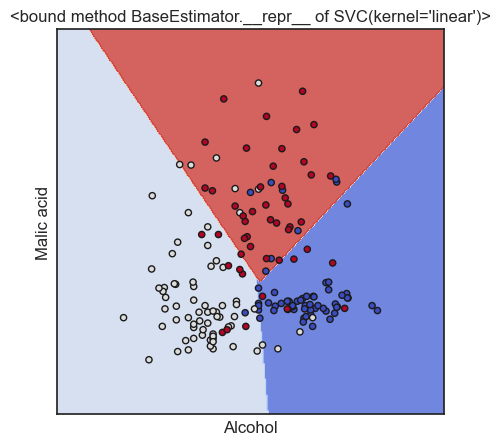

In [44]:
plot_cl(SVC(kernel='linear', C=1.0))

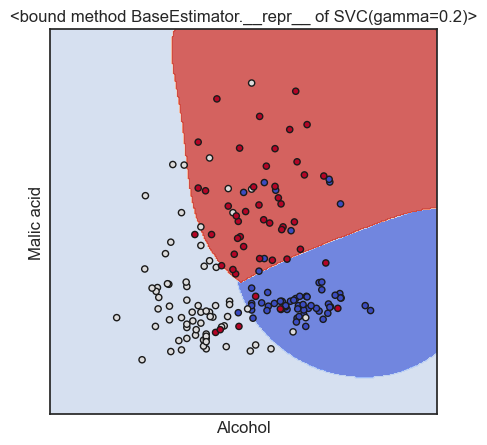

In [46]:
plot_cl(SVC(kernel='rbf', gamma=0.2, C=1.0))

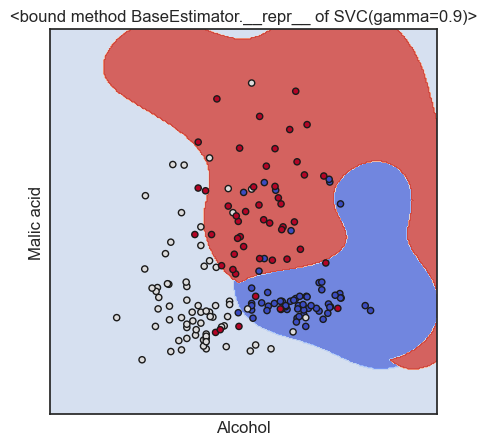

In [47]:
plot_cl(SVC(kernel='rbf', gamma=0.9, C=1.0))

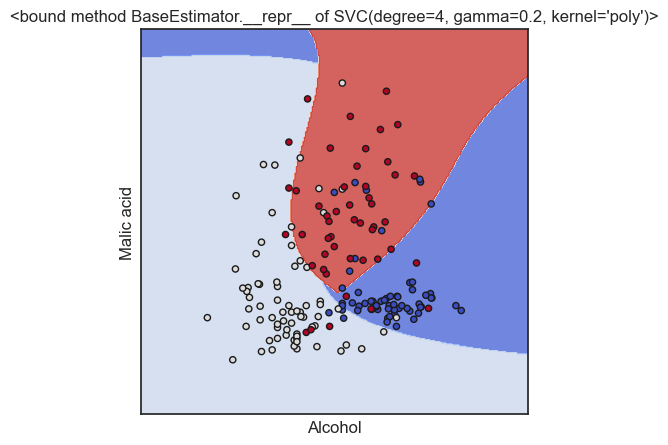

In [48]:
plot_cl(SVC(kernel='poly', degree=4, gamma=0.2, C=1.0))

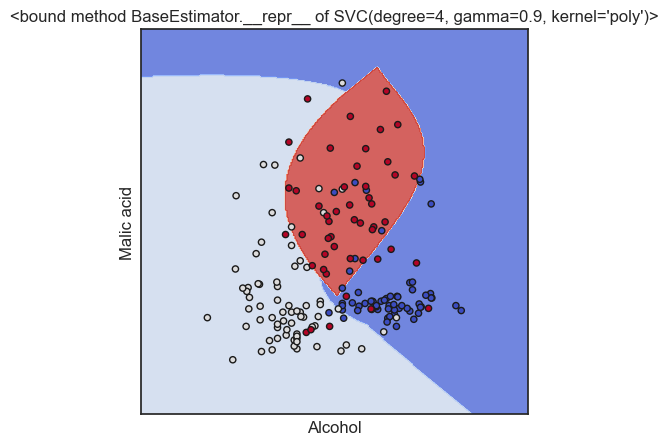

In [49]:
plot_cl(SVC(kernel='poly', degree=4, gamma=0.9, C=1.0))

In [57]:
df_wine = pd.DataFrame(wine.data,columns=wine.feature_names)
df_wine['target'] = pd.Series(wine.target)
wine_x = df_wine['flavanoids'].values 
wine_y = df_wine['target'].values

<Axes: >

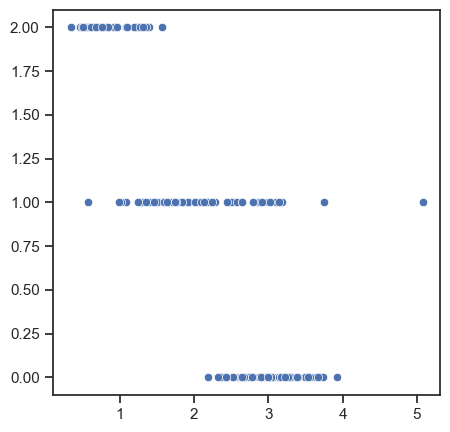

In [58]:
fig, ax = plt.subplots(figsize=(5,5)) 
sns.scatterplot(ax=ax, x=wine_x, y=wine_y)

In [59]:
def plot_regr(clf):
    title = clf.__repr__
    clf.fit(wine_x.reshape(-1, 1), wine_y)
    wine_y_pred = clf.predict(wine_x.reshape(-1, 1))
    fig, ax = plt.subplots(figsize=(5,5))
    ax.set_title(title)
    ax.plot(wine_x, wine_y, 'b.')
    ax.plot(wine_x, wine_y_pred, 'ro')
    plt.show()

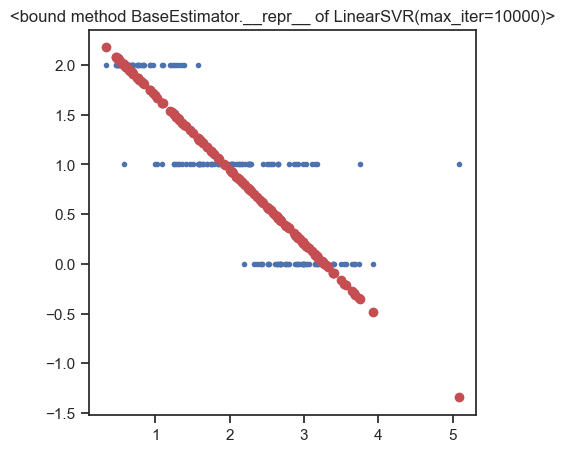

In [60]:
plot_regr(LinearSVR(C=1.0, max_iter=10000))

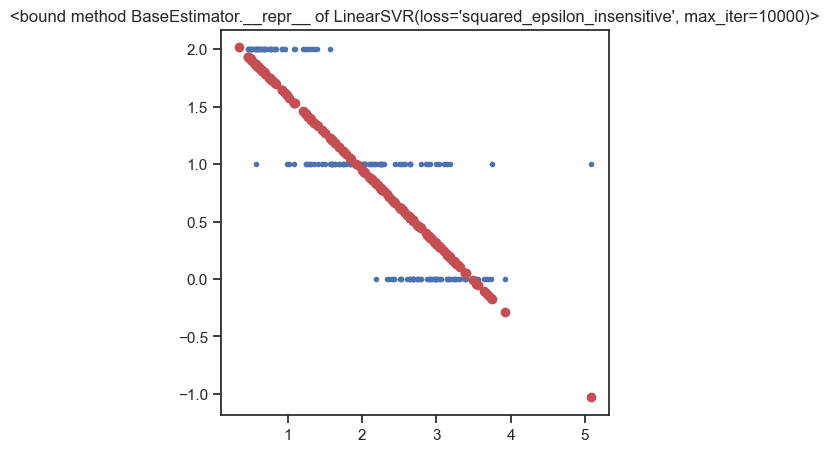

In [61]:
plot_regr(LinearSVR(C=1.0, loss='squared_epsilon_insensitive', max_iter=10000))

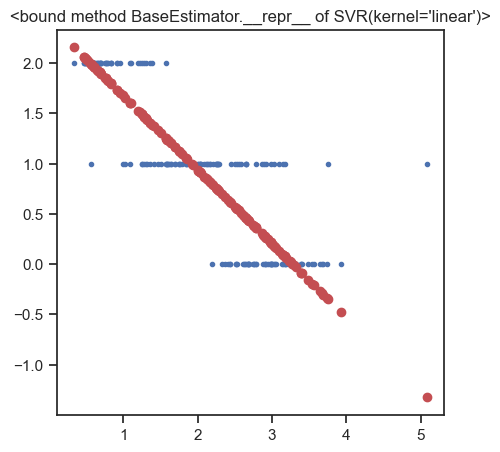

In [62]:
plot_regr(SVR(kernel='linear', C=1.0))

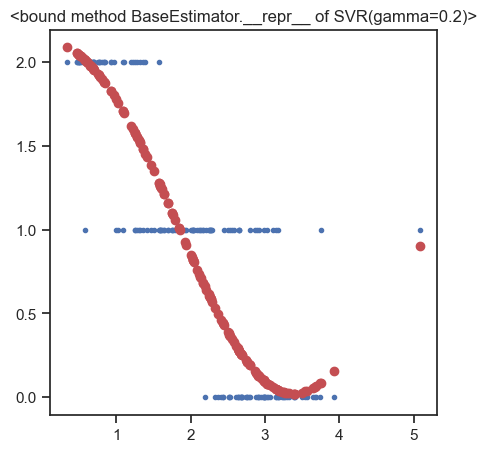

In [63]:
plot_regr(SVR(kernel='rbf', gamma=0.2, C=1.0))

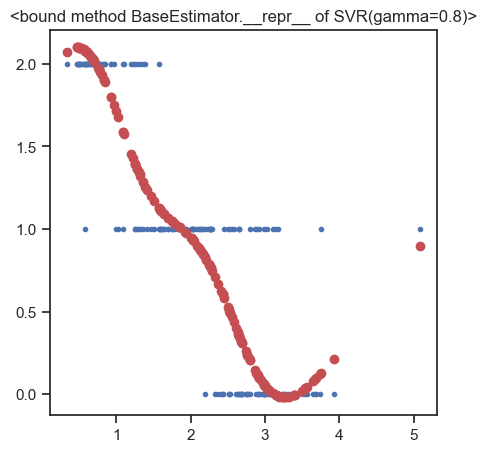

In [64]:
plot_regr(SVR(kernel='rbf', gamma=0.8, C=1.0))

In [65]:
def random_dataset_for_regression():
    """
    Создание случайного набора данных для регрессии
    """
    rng = np.random.RandomState(1)
    X_train = np.sort(5 * rng.rand(80, 1), axis=0)
    y_train = np.sin(X_train).ravel()
    y_train[::5] += 3 * (0.5 - rng.rand(16))
    X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
    return X_train, y_train, X_test

In [66]:
def plot_tree_regression(X_train, y_train, X_test):
    """
    Построение деревьев и вывод графиков для заданного датасета
    """

    # Обучение регрессионной модели
    regr_1 = DecisionTreeRegressor(max_depth=3)
    regr_2 = DecisionTreeRegressor(max_depth=10)
    regr_1.fit(X_train, y_train)
    regr_2.fit(X_train, y_train)

    # Предсказание
    y_1 = regr_1.predict(X_test)
    y_2 = regr_2.predict(X_test)

    # Вывод графика
    fig, ax = plt.subplots(figsize=(15,7))
    plt.scatter(X_train, y_train, s=20, edgecolor="black", c="darkorange", label="Данные")
    plt.plot(X_test, y_1, color="cornflowerblue", label="max_depth=3", linewidth=2)
    plt.plot(X_test, y_2, color="yellowgreen", label="max_depth=10", linewidth=2)
    plt.xlabel("Данные")
    plt.ylabel("Целевой признак")
    plt.title("Регрессия на основе дерева решений")
    plt.legend()
    plt.show()

In [68]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz

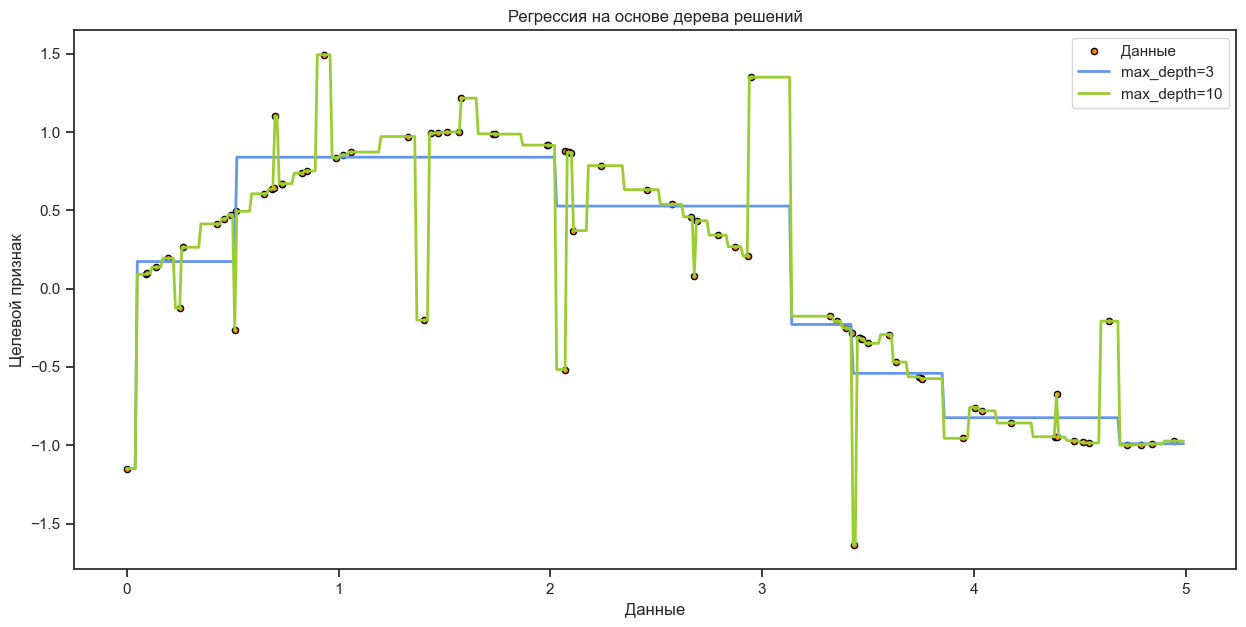

In [69]:
X_train, y_train, X_test = random_dataset_for_regression()
plot_tree_regression(X_train, y_train, X_test)

In [70]:
wine_tree_regr = DecisionTreeRegressor(random_state=1)
wine_tree_regr.fit(df_wine, wine.target)
wine_tree_regr

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [80]:
!pip install pydotplus

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pydotplus: filename=pydotplus-2.0.2-py3-none-any.whl size=24659 sha256=32bb4d0ad415439c1d99e5e6279aa542a686cd1713ccfd638b5a61d8e8e1213f
  Stored in directory: c:\users\masha\appdata\local\pip\cache\wheels\4a\c0\ed\a9eeeb08c3c53bb90d3822cf76557c8fdcbc349ee11a011169
Successfully built pydotplus


In [84]:
!pip install graphviz

In [85]:
from io import StringIO 
from IPython.display import Image
import graphviz 
import pydotplus

In [89]:
# Визуализация дерева
def get_png_tree(tree_model_param, feature_names_param):
    dot_data = StringIO()
    export_graphviz(tree_model_param, out_file=dot_data, feature_names=feature_names_param,
                    filled=True, rounded=True, special_characters=True)
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    return graph.create_png()

In [103]:
# Обучим дерево на всех признаках boston c ограничением глубины дерева
wine_tree_regr_prun = DecisionTreeRegressor(random_state=1, max_depth=3)
wine_tree_regr_prun.fit(df_wine, wine.target)
wine_tree_regr_prun

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [104]:
Image(get_png_tree(wine_tree_regr_prun, df_wine.columns), height='70%')

InvocationException: GraphViz's executables not found

In [105]:
sum(wine_tree_regr.feature_importances_)

np.float64(1.0)

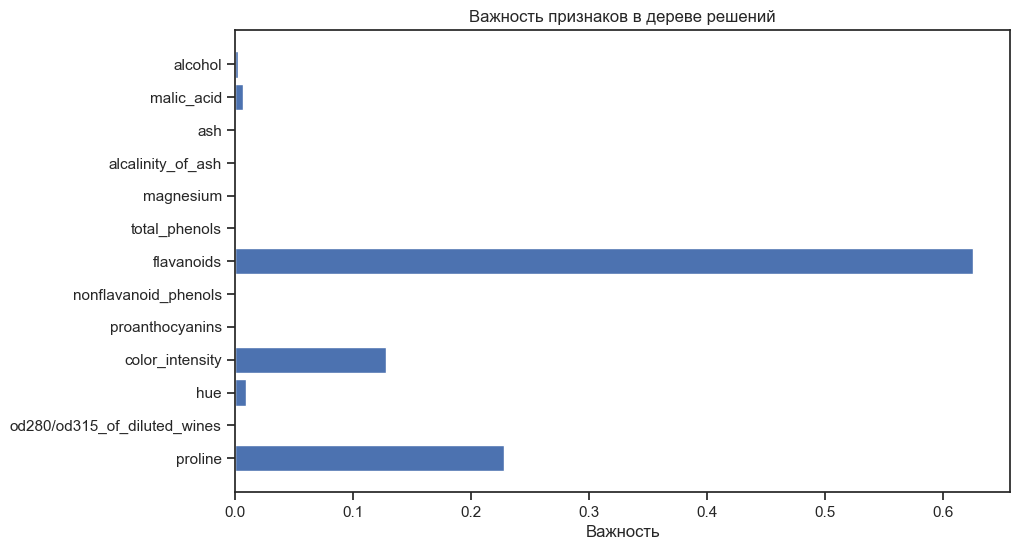

In [107]:
def draw_feature_importances(model, df):
    importances = model.feature_importances_
    
    plt.figure(figsize=(10, 6))
    plt.barh(df.columns, importances)
    plt.xlabel("Важность")
    plt.title("Важность признаков в дереве решений")
    plt.gca().invert_yaxis()
    plt.show()
    
    return importances

# Использование
wine_tree_regr_f1 = draw_feature_importances(wine_tree_regr, df_wine)

In [110]:
wine_tree_regr_f1[0:5]

array([0.00217721, 0.00705416, 0.        , 0.        , 0.        ])

In [112]:
sum(wine_tree_regr_f1[0:5])

np.float64(0.009231371397817887)